In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals


sys.path.append("/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools")
import plotTools as ptools
import utils

In [2]:
f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/AllInOne_2022/Big_Resolution_dask.coffea"
# f_sig = "/uscms/home/reshmar/nobackup/IDMe_Run3_Collab/CMSSW_13_0_13/src/iDMe/python_analysis/coffea/BigSamples_2022/Futures_Resolution.coffea"

sig_histo = util.load(f_sig) [0]
# sig_histo

sig_2022_Mchi-11p0_dMchi-2p0_ctau-100
Hist(
  Variable([0, 1, 3, 6, 10, 15], name='Gen_vxy'),
  Regular(700, -0.5, 0.5, name='Res_LPT'),
  storage=Weight()) # Sum: WeightedSum(value=2491, variance=2491) (WeightedSum(value=2506, variance=2506) with flow)
sig_2022_Mchi-22p0_dMchi-4p0_ctau-100
sig_2022_Mchi-33p0_dMchi-6p0_ctau-100
sig_2022_Mchi-44p0_dMchi-8p0_ctau-100
sig_2022_Mchi-55p0_dMchi-10p0_ctau-100
sig_2022_Mchi-63p0_dMchi-6p0_ctau-100
sig_2022_Mchi-66p0_dMchi-12p0_ctau-100
sig_2022_Mchi-73p5_dMchi-7p0_ctau-100
sig_2022_Mchi-77p0_dMchi-14p0_ctau-100
sig_2022_Mchi-84p0_dMchi-8p0_ctau-100
sig_2022_Mchi-88p0_dMchi-16p0_ctau-100
sig_2022_Mchi-94p5_dMchi-9p0_ctau-100
sig_2022_Mchi-99p0_dMchi-18p0_ctau-100
sig_2022_Mchi-105p0_dMchi-10p0_ctau-100
sig_2022_Mchi-110p0_dMchi-20p0_ctau-100


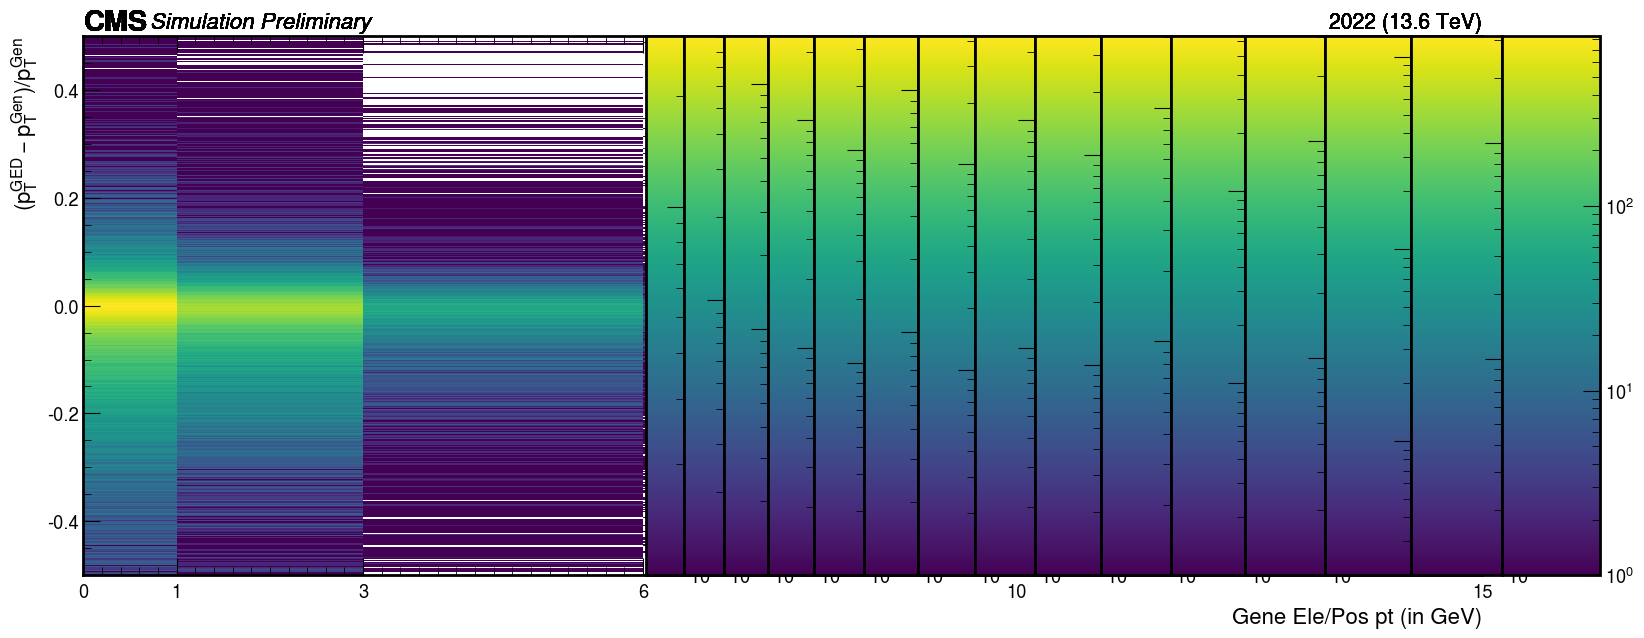

In [3]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_LPT_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}


samples = {
    10: 
    {
        
        0.2: [100],
    },
    20: 
    {
        
        0.2: [100],
        
    },
    30: 
    {
       
        0.2: [100]
    },
    40: 
    {
        0.2: [100],
    },
    50:
    {
        
        0.2: [100],
    },
    60:
    {
        
         0.1: [100],
         0.2: [100]
    
    },
    70:
    {    0.1: [100],
         0.2: [100],
    },
    80:
    {    0.1: [100],
         0.2: [100],
    },
    90:
    {    0.1: [100],
         0.2: [100],
    },
    100:
    {    0.1: [100],
         0.2: [100],
    }
 
}

h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



In [4]:
print (h_sum_lpt)

Hist(
  Variable([0, 1, 3, 6, 10, 15], name='Gen_vxy'),
  Regular(700, -0.5, 0.5, name='Res_LPT'),
  storage=Weight()) # Sum: WeightedSum(value=506601, variance=506601) (WeightedSum(value=510446, variance=510446) with flow)


# Selective DSCB fit tuning for poor pT bins only

This section tunes **only pT-bin indices 0, 1, and 2**.  Bins **3 and 4 are controls and are intentionally left at the original settings**:

- residual bin width = `0.01`
- fit range = `[-0.30, 0.30]`
- same DSCB model, initial-guess prescription, bounds, and `curve_fit` options

The tuning is done in two controlled stages:

1. **Fit-range scan** for bins 0–2, using the original 0.01 residual binning.
2. **Optional 0.02 rebin test** only if a tuned bin still has poor chi2/ndof.  The wider binning is accepted only when it improves chi2/ndof and keeps fitted sigma reasonably stable.

This avoids changing several fit ingredients at once and makes it clear what improved each fit.

In [5]:
# ============================================================
# GLOBAL SETTINGS
# ============================================================

# Original settings used for the already-good bins 3 and 4.
ORIGINAL_RES_BIN_WIDTH = 0.01
ORIGINAL_FIT_RANGE = (-0.30, 0.30)

# Display range only; does not affect the fit.
plot_min = -0.50
plot_max =  0.50

# Only these bins are allowed to be tuned.
TUNE_BINS = {0, 1, 2}
LOCKED_BINS = {3, 4}

# Predefined range candidates.  The original range is always included.
fit_range_candidates = {
    0: [(-0.30, 0.30), (-0.25, 0.25), (-0.20, 0.20), (-0.20, 0.15), (-0.15, 0.15)],
    1: [(-0.30, 0.30), (-0.25, 0.25), (-0.20, 0.20), (-0.20, 0.15), (-0.15, 0.15)],
    2: [(-0.30, 0.30), (-0.25, 0.25), (-0.25, 0.20), (-0.20, 0.20), (-0.20, 0.15)],
}

# Prevent choosing a dramatically different sigma just to lower chi2.
MAX_SIGMA_REL_CHANGE = 0.10   # 10% relative to the original-range fit

# Stage 2 is only attempted when Stage 1 remains above this value.
CHI2NDOF_FOR_REBIN_TEST = 2.0
COARSER_RES_BIN_WIDTH = 0.02

print('Bins allowed to change :', sorted(TUNE_BINS))
print('Bins locked/unmodified :', sorted(LOCKED_BINS))

Bins allowed to change : [0, 1, 2]
Bins locked/unmodified : [3, 4]


In [6]:
# ============================================================
# HELPERS: selective rebinning + extraction of one pT bin
# ============================================================

def _rebin_hist_to_width(h, desired_width):
    """Return h rebinned along the residual axis to desired_width."""
    original_edges = h.axes[1].edges
    original_widths = np.diff(original_edges)

    if not np.allclose(original_widths, original_widths[0]):
        raise ValueError(
            'The stored residual axis has variable-width bins. '
            'Use an explicit grouping scheme instead.'
        )

    original_width = original_widths[0]
    factor = int(round(desired_width / original_width))

    if factor < 1:
        raise ValueError('Requested width is finer than the stored histogram.')

    actual_width = factor * original_width
    if not np.isclose(actual_width, desired_width):
        raise ValueError(
            f'Requested width {desired_width:g} is not an integer multiple '
            f'of stored width {original_width:g}.'
        )

    return h[:, hist.rebin(factor)], factor, actual_width


def make_bin_data(ptbin_index, res_bin_width=ORIGINAL_RES_BIN_WIDTH):
    """Extract x, y, uncertainty and pT range for one pT-bin index."""
    h_use, factor, actual_width = _rebin_hist_to_width(h_sum_lpt, res_bin_width)

    pt_low = h_use.axes[0].edges[ptbin_index]
    pt_high = h_use.axes[0].edges[ptbin_index + 1]

    y = h_use[ptbin_index, :].values()
    variances = h_use[ptbin_index, :].variances()
    yerr = np.sqrt(variances)
    edges = h_use.axes[1].edges
    x = 0.5 * (edges[:-1] + edges[1:])

    return {
        'ptbin_index': ptbin_index,
        'genpt_bin': (pt_low, pt_high),
        'xdata': x,
        'ydata': y,
        'yerror': yerr,
        'res_bin_width': actual_width,
        'rebin_factor': factor,
        'hist': h_use,
    }

# Verify the original 0.01 setting used by bins 3 and 4.
_, original_rebin_factor, actual_original_width = _rebin_hist_to_width(
    h_sum_lpt, ORIGINAL_RES_BIN_WIDTH
)
print(f'Stored residual bin width : {np.diff(h_sum_lpt.axes[1].edges)[0]:g}')
print(f'Original rebin factor      : {original_rebin_factor}')
print(f'Original fitted bin width  : {actual_original_width:g}')

Stored residual bin width : 0.00142857
Original rebin factor      : 7
Original fitted bin width  : 0.01


In [7]:
# ============================================================
# DSCB MODEL -- unchanged from the original notebook
# ============================================================

def double_cb(x, u, sig, nl, a_l, nr, a_r, N):
    t = (x-u)/sig
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t >= -al) & (t <= ar)
    right_tail = t > ar

    y = np.empty_like(t)
    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl/al)**nl * np.exp(-0.5*al**2)
    B_L = (nl/al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr/ar)**nr * np.exp(-0.5*ar**2)
    B_R = (nr/ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y

In [8]:
# ============================================================
# ONE FIT FUNCTION -- same fit prescription as the original notebook
# ============================================================
from scipy.optimize import curve_fit

N_PARAMETERS = 7


def fit_one_bin(ptbin_index, fit_range, res_bin_width=ORIGINAL_RES_BIN_WIDTH):
    data = make_bin_data(ptbin_index, res_bin_width=res_bin_width)
    x = data['xdata']
    y = data['ydata']
    sig_y = data['yerror']

    fit_min_i, fit_max_i = fit_range
    mask = (y > 0) & (sig_y > 0) & (x >= fit_min_i) & (x <= fit_max_i)

    xfit = x[mask]
    yfit = y[mask]
    yerrfit = sig_y[mask]

    if len(xfit) <= N_PARAMETERS:
        raise ValueError(
            f'pT-bin {ptbin_index}: only {len(xfit)} populated points in range {fit_range}.'
        )

    mean0 = np.average(xfit, weights=yfit)
    sigma0 = np.sqrt(np.average((xfit-mean0)**2, weights=yfit))

    # Unchanged parameter order and starting prescription:
    # [mean, sigma, nL, alphaL, nR, alphaR, N]
    initial_guess = [mean0, sigma0, 1, 0.2, 1, 0.2, yfit.max()]

    # Unchanged bounds prescription.
    lower = [xfit.min(), 1e-5, 0.5, 0.05, 0.1, 0.05, 0]
    upper = [xfit.max(), xfit.max()-xfit.min(), 2, 1, 5, 2, 5*yfit.max()]

    popt, pcov = curve_fit(
        double_cb,
        xfit,
        yfit,
        p0=initial_guess,
        sigma=yerrfit,
        absolute_sigma=True,
        bounds=(lower, upper),
        maxfev=20000,
    )

    perr = np.sqrt(np.diag(pcov))
    yp = double_cb(xfit, *popt)
    chi2 = np.sum(((yfit-yp)/yerrfit)**2)
    ndof = len(xfit) - len(popt)
    chi2ndof = chi2/ndof

    return {
        **data,
        'fit_range': fit_range,
        'xfit': xfit,
        'yfit': yfit,
        'yerrfit': yerrfit,
        'popt': popt,
        'perr': perr,
        'chi2': chi2,
        'ndof': ndof,
        'chi2/ndof': chi2ndof,
        'fit_mean': popt[0],
        'fit_mean_unc': perr[0],
        'fit_sigma': popt[1],
        'fit_sigma_unc': perr[1],
    }

## Step 1 — scan the fit range for bins 0, 1, and 2 only

All scans below use the **original residual bin width of 0.01**.  Bins 3 and 4 are not included in this scan.

To avoid artificially obtaining a better chi2 by choosing a range that produces a very different resolution, the automatic choice requires fitted sigma to stay within **10% of the original-range sigma**.  Among those stable candidates, it chooses the lowest chi2/ndof.

In [9]:
range_scan_rows = []
range_scan_fits = {}
selected_fit_ranges = {}

for idx in sorted(TUNE_BINS):
    range_scan_fits[idx] = {}

    # Baseline = exactly the original fit settings.
    baseline = fit_one_bin(idx, ORIGINAL_FIT_RANGE, ORIGINAL_RES_BIN_WIDTH)
    baseline_sigma = baseline['fit_sigma']

    for fit_range in fit_range_candidates[idx]:
        result = fit_one_bin(idx, fit_range, ORIGINAL_RES_BIN_WIDTH)
        range_scan_fits[idx][fit_range] = result

        sigma_rel_change = abs(result['fit_sigma'] - baseline_sigma) / baseline_sigma
        sigma_stable = sigma_rel_change <= MAX_SIGMA_REL_CHANGE

        range_scan_rows.append({
            'pT bin index': idx,
            'fit range': str(fit_range),
            'bin width': result['res_bin_width'],
            'sigma': result['fit_sigma'],
            'sigma unc': result['fit_sigma_unc'],
            'sigma change vs original': sigma_rel_change,
            'chi2/ndof': result['chi2/ndof'],
            'ndof': result['ndof'],
            'sigma stable': sigma_stable,
        })

    stable_results = [
        r for r in range_scan_fits[idx].values()
        if abs(r['fit_sigma'] - baseline_sigma) / baseline_sigma <= MAX_SIGMA_REL_CHANGE
    ]

    # Original range is always stable with respect to itself, so this should be non-empty.
    best = min(stable_results, key=lambda r: r['chi2/ndof'])
    selected_fit_ranges[idx] = best['fit_range']

range_scan_df = pd.DataFrame(range_scan_rows)
display(range_scan_df)

print('\nSelected range after Stage 1:')
for idx in sorted(TUNE_BINS):
    r = range_scan_fits[idx][selected_fit_ranges[idx]]
    print(
        f'  bin {idx}: {selected_fit_ranges[idx]}  '
        f'chi2/ndof={r["chi2/ndof"]:.3f}, sigma={r["fit_sigma"]:.5f}'
    )

,pT bin index,fit range,bin width,sigma,sigma unc,sigma change vs original,chi2/ndof,ndof,sigma stable
0,0,"(-0.3, 0.3)",0.01,0.019786,0.000152,0.000000,4.159489,53,True
1,0,"(-0.25, 0.25)",0.01,0.019986,0.000151,0.010096,2.537977,43,True
2,0,"(-0.2, 0.2)",0.01,0.020119,0.000151,0.016816,2.057355,33,True
3,0,"(-0.2, 0.15)",0.01,0.020102,0.000154,0.015971,2.382229,28,True
4,0,"(-0.15, 0.15)",0.01,0.020179,0.000154,0.019877,2.539740,23,True
5,1,"(-0.3, 0.3)",0.01,0.019983,0.000207,0.000000,3.662351,53,True
6,1,"(-0.25, 0.25)",0.01,0.020126,0.000209,0.007124,2.197217,43,True
7,1,"(-0.2, 0.2)",0.01,0.020289,0.000209,0.015278,1.296759,33,True
8,1,"(-0.2, 0.15)",0.01,0.020274,0.000213,0.014547,1.495282,28,True
9,1,"(-0.15, 0.15)",0.01,0.020320,0.000215,0.016875,1.743463,23,True



Selected range after Stage 1:
  bin 0: (-0.2, 0.2)  chi2/ndof=2.057, sigma=0.02012
  bin 1: (-0.2, 0.2)  chi2/ndof=1.297, sigma=0.02029
  bin 2: (-0.2, 0.2)  chi2/ndof=1.819, sigma=0.02100


## Step 1 visual check — only the poor bins

This overlays the original-range fit and the selected-range fit for pT-bin indices 0–2.  The histogram itself is unchanged.

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


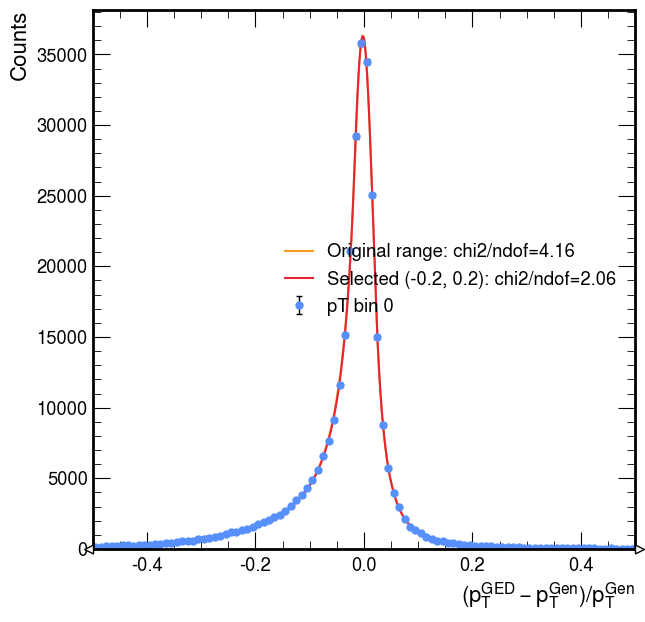

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


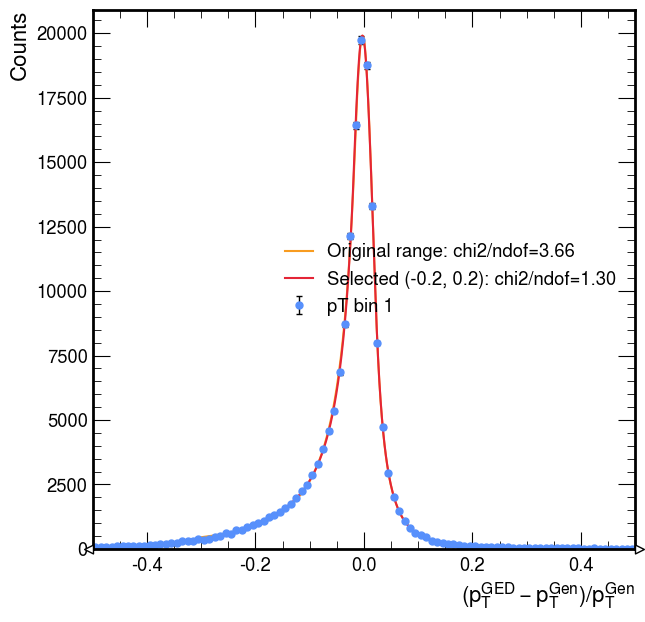

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


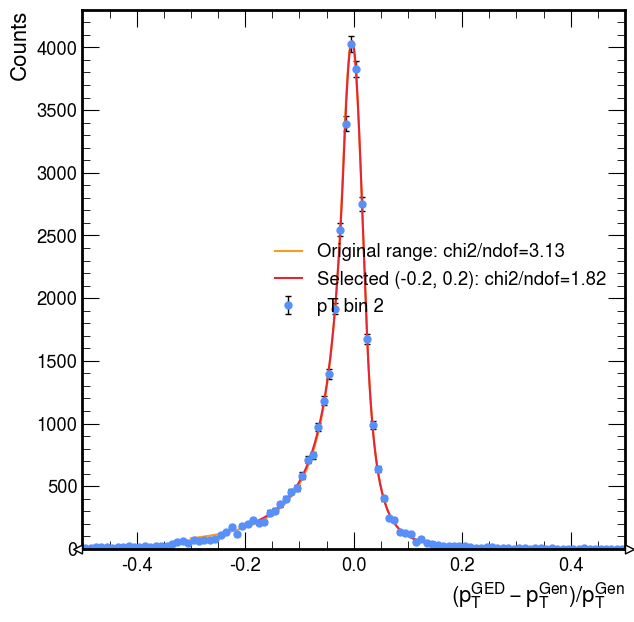

In [10]:
for idx in sorted(TUNE_BINS):
    original_result = range_scan_fits[idx][ORIGINAL_FIT_RANGE]
    selected_result = range_scan_fits[idx][selected_fit_ranges[idx]]

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        original_result['hist'][idx, :],
        histtype='errorbar', yerr=True, fmt='o', capsize=2,
        ecolor='black', label=f'pT bin {idx}'
    )

    x_original = np.linspace(*ORIGINAL_FIT_RANGE, 500)
    plt.plot(
        x_original,
        double_cb(x_original, *original_result['popt']),
        label=f'Original range: chi2/ndof={original_result["chi2/ndof"]:.2f}'
    )

    x_selected = np.linspace(*selected_result['fit_range'], 500)
    plt.plot(
        x_selected,
        double_cb(x_selected, *selected_result['popt']),
        label=(f'Selected {selected_result["fit_range"]}: '
               f'chi2/ndof={selected_result["chi2/ndof"]:.2f}')
    )

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(p_T^{GED}-p_T^{Gen})/p_T^{Gen}$')
    plt.ylabel('Counts')
    plt.legend()
    plt.show()

## Step 2 — test 0.02 binning only when Stage 1 is still poor

This step still acts **only on bins 0–2**.  For a tuned bin whose Stage-1 chi2/ndof is above 2, the notebook compares residual widths 0.01 and 0.02 at the already-selected fit range.

The 0.02 option is accepted only if:

- chi2/ndof decreases, **and**
- fitted sigma changes by no more than 10% relative to the 0.01 result.

Bins 3 and 4 never enter this test and remain at 0.01.

In [11]:
selected_res_bin_widths = {0: ORIGINAL_RES_BIN_WIDTH,
                           1: ORIGINAL_RES_BIN_WIDTH,
                           2: ORIGINAL_RES_BIN_WIDTH,
                           3: ORIGINAL_RES_BIN_WIDTH,
                           4: ORIGINAL_RES_BIN_WIDTH}

rebin_scan_rows = []

for idx in sorted(TUNE_BINS):
    fit_range = selected_fit_ranges[idx]
    fine = fit_one_bin(idx, fit_range, ORIGINAL_RES_BIN_WIDTH)

    rebin_scan_rows.append({
        'pT bin index': idx,
        'fit range': str(fit_range),
        'bin width': fine['res_bin_width'],
        'sigma': fine['fit_sigma'],
        'chi2/ndof': fine['chi2/ndof'],
        'selected': True,   # may be updated below
        'note': 'Stage-1 result',
    })

    if fine['chi2/ndof'] > CHI2NDOF_FOR_REBIN_TEST:
        coarse = fit_one_bin(idx, fit_range, COARSER_RES_BIN_WIDTH)
        sigma_rel_change = abs(coarse['fit_sigma'] - fine['fit_sigma']) / fine['fit_sigma']
        accept_coarse = (
            coarse['chi2/ndof'] < fine['chi2/ndof']
            and sigma_rel_change <= MAX_SIGMA_REL_CHANGE
        )

        if accept_coarse:
            selected_res_bin_widths[idx] = COARSER_RES_BIN_WIDTH
            rebin_scan_rows[-1]['selected'] = False

        rebin_scan_rows.append({
            'pT bin index': idx,
            'fit range': str(fit_range),
            'bin width': coarse['res_bin_width'],
            'sigma': coarse['fit_sigma'],
            'chi2/ndof': coarse['chi2/ndof'],
            'selected': accept_coarse,
            'note': f'sigma change={sigma_rel_change:.1%}',
        })

rebin_scan_df = pd.DataFrame(rebin_scan_rows)
display(rebin_scan_df)

print('\nFinal selective settings:')
for idx in range(5):
    fit_range = selected_fit_ranges[idx] if idx in TUNE_BINS else ORIGINAL_FIT_RANGE
    width = selected_res_bin_widths[idx]
    status = 'TUNED' if idx in TUNE_BINS else 'LOCKED / original'
    print(f'  bin {idx}: range={fit_range}, bin width={width:g}   [{status}]')

,pT bin index,fit range,bin width,sigma,chi2/ndof,selected,note
0,0,"(-0.2, 0.2)",0.01,0.020119,2.057355,True,Stage-1 result
1,0,"(-0.2, 0.2)",0.02,0.021909,2.470015,False,sigma change=8.9%
2,1,"(-0.2, 0.2)",0.01,0.020289,1.296759,True,Stage-1 result
3,2,"(-0.2, 0.2)",0.01,0.021004,1.819480,True,Stage-1 result



Final selective settings:
  bin 0: range=(-0.2, 0.2), bin width=0.01   [TUNED]
  bin 1: range=(-0.2, 0.2), bin width=0.01   [TUNED]
  bin 2: range=(-0.2, 0.2), bin width=0.01   [TUNED]
  bin 3: range=(-0.3, 0.3), bin width=0.01   [LOCKED / original]
  bin 4: range=(-0.3, 0.3), bin width=0.01   [LOCKED / original]


## Final fits

The final cell below uses the settings selected above for bins 0–2.  For bins **3 and 4**, it explicitly restores the original `[-0.30, 0.30]` range and `0.01` bin width.

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


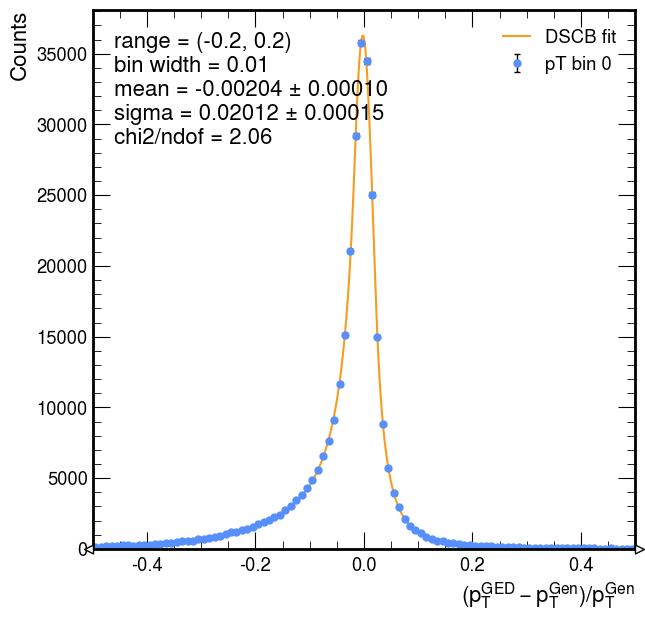

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


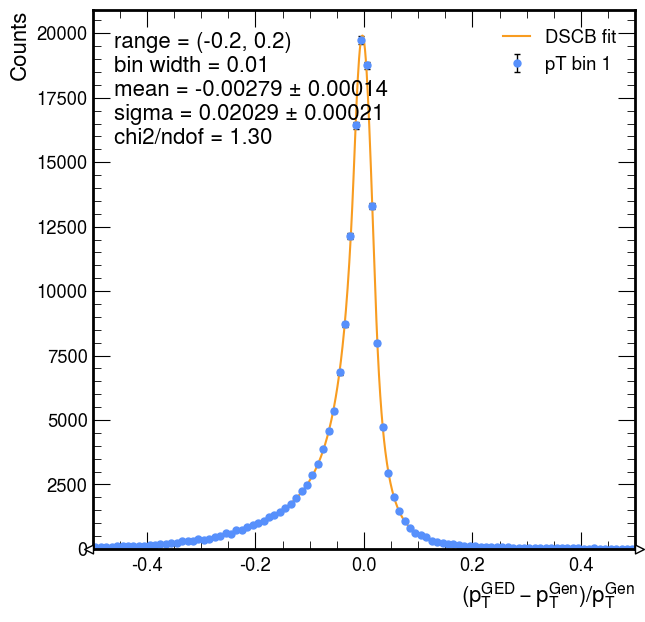

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


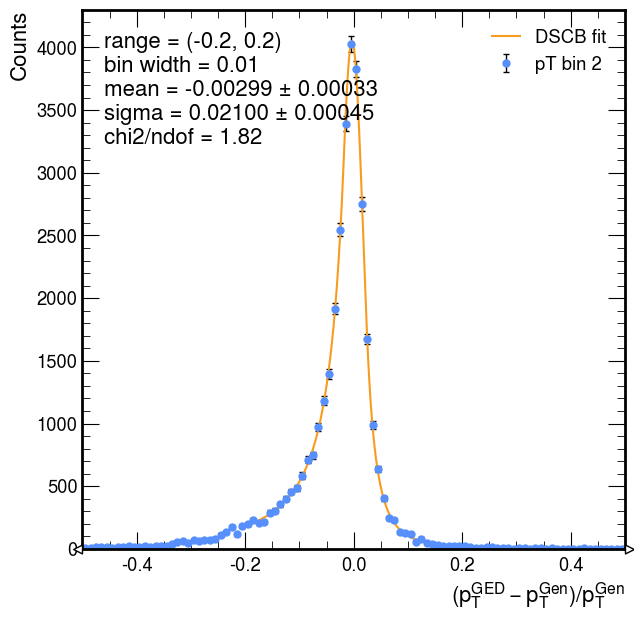

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


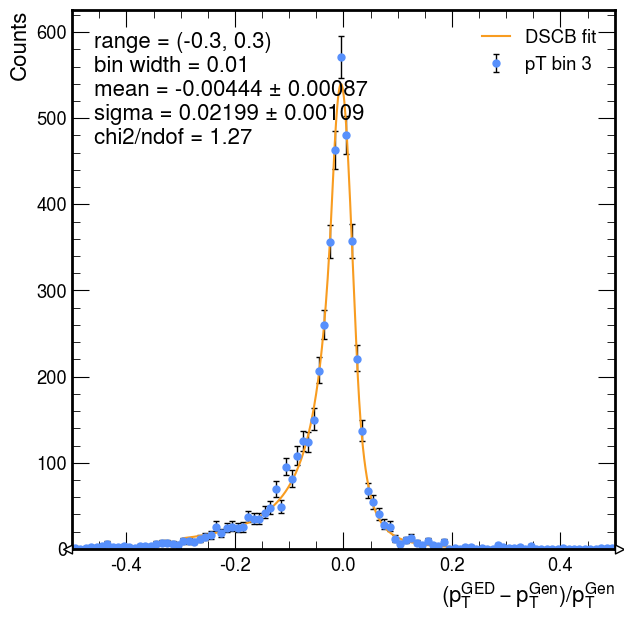

/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(


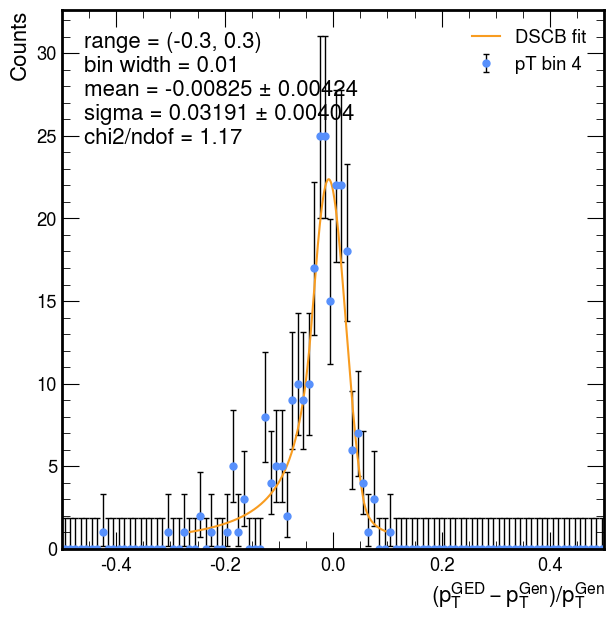

,pT bin index,genptbin_range,fit_mean,fit_mean_unc,fit_sigma,fit_sigma_unc,chi2/ndof,fit_range,res_bin_width
0,0,"(0.0, 1.0)",-0.002042,0.000099,0.020119,0.000151,2.057355,"(-0.2, 0.2)",0.01
1,1,"(1.0, 3.0)",-0.002788,0.000141,0.020289,0.000209,1.296759,"(-0.2, 0.2)",0.01
2,2,"(3.0, 6.0)",-0.002988,0.000329,0.021004,0.000446,1.819480,"(-0.2, 0.2)",0.01
3,3,"(6.0, 10.0)",-0.004437,0.000868,0.021986,0.001095,1.270631,"(-0.3, 0.3)",0.01
4,4,"(10.0, 15.0)",-0.008251,0.004236,0.031914,0.004041,1.171638,"(-0.3, 0.3)",0.01


In [12]:
fit_data = []
final_fit_results = {}

for idx in range(len(h_sum_lpt.axes[0].edges)-1):
    if idx in TUNE_BINS:
        fit_range = selected_fit_ranges[idx]
        res_width = selected_res_bin_widths[idx]
    else:
        # IMPORTANT: bins 3 and 4 are untouched.
        fit_range = ORIGINAL_FIT_RANGE
        res_width = ORIGINAL_RES_BIN_WIDTH

    result = fit_one_bin(idx, fit_range, res_width)
    final_fit_results[idx] = result

    fit_data.append({
        'pT bin index': idx,
        'genptbin_range': result['genpt_bin'],
        'fit_mean': result['fit_mean'],
        'fit_mean_unc': result['fit_mean_unc'],
        'fit_sigma': result['fit_sigma'],
        'fit_sigma_unc': result['fit_sigma_unc'],
        'chi2/ndof': result['chi2/ndof'],
        'fit_range': result['fit_range'],
        'res_bin_width': result['res_bin_width'],
    })

    plt.figure(figsize=(7, 7))
    mplhep.histplot(
        result['hist'][idx, :],
        histtype='errorbar', yerr=True, fmt='o', capsize=2,
        ecolor='black', label=f'pT bin {idx}'
    )

    x_fit_plot = np.linspace(result['xfit'].min(), result['xfit'].max(), 500)
    plt.plot(x_fit_plot, double_cb(x_fit_plot, *result['popt']), label='DSCB fit')

    plt.xlim(plot_min, plot_max)
    plt.xlabel(r'$(p_T^{GED}-p_T^{Gen})/p_T^{Gen}$')
    plt.ylabel('Counts')
    plt.text(
        0.04, 0.96,
        (f'range = {result["fit_range"]}\n'
         f'bin width = {result["res_bin_width"]:g}\n'
         f'mean = {result["fit_mean"]:.5f} ± {result["fit_mean_unc"]:.5f}\n'
         f'sigma = {result["fit_sigma"]:.5f} ± {result["fit_sigma_unc"]:.5f}\n'
         f'chi2/ndof = {result["chi2/ndof"]:.2f}'),
        transform=plt.gca().transAxes,
        va='top'
    )
    plt.legend()
    plt.show()

fit_df = pd.DataFrame(fit_data)
display(fit_df)

[0.0, 1.0, 3.0, 6.0, 10.0, 15.0]


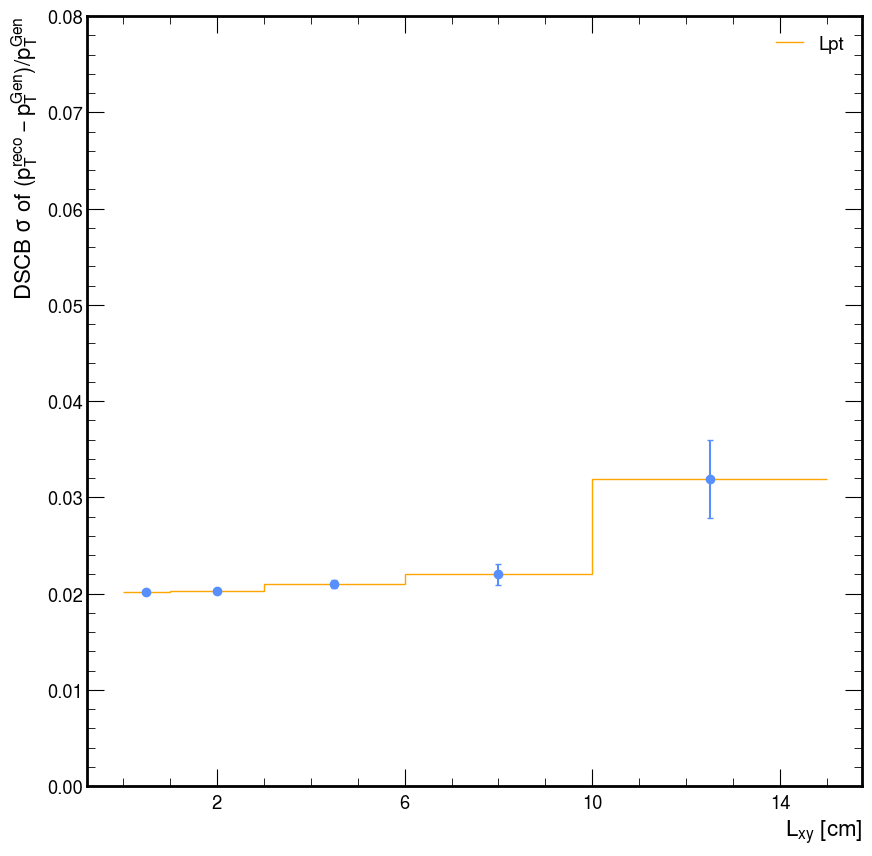

In [15]:
# ============================================================
# Resolution summary plot -- same downstream quantity as before
# ============================================================
plot_data = []
genpt_edges = []

for i in fit_data:
    pt_low, pt_high = i['genptbin_range']
    pt_center = (pt_low + pt_high) / 2

    if not genpt_edges:
        genpt_edges.append(pt_low)
    genpt_edges.append(pt_high)

    plot_data.append({
        'Genpt_center': pt_center,
        'DSCB sigmafit': round(i['fit_sigma'], 5),
        'sigma_unc': round(i['fit_sigma_unc'], 5),
    })

print(genpt_edges)

genpt = [p['Genpt_center'] for p in plot_data]
sigma = [p['DSCB sigmafit'] for p in plot_data]
sigma_unc = [p['sigma_unc'] for p in plot_data]

plt.stairs(sigma, genpt_edges, baseline=None, color='orange', label='Lpt')
plt.errorbar(genpt, sigma, yerr=sigma_unc, fmt='o', capsize=2)
plt.xticks(np.arange(2, 17, 4))
plt.ylim(0, 0.08)
plt.xlabel(r'$L_{xy}\ \mathrm{[cm]}$')
plt.ylabel(r'DSCB $\sigma$ of $(p_T^{\mathrm{reco}}-p_T^{\mathrm{Gen}})/p_T^{\mathrm{Gen}}$')
plt.legend()
plt.show()

### What to inspect after running

The two tables are the important diagnostics.  First check the **range-scan table** for bins 0–2, then the **0.01 vs 0.02 table** for any bin that remained above chi2/ndof = 2.  The final table records the exact range and residual-bin width used for every pT bin, so it is easy to verify that indices 3 and 4 stayed unchanged.